# 04 — Hierarchical Partitioning Sweep (L)

Two-tier composition (`03_hierarchical_topologies.md` §2.1):

```
AR  ≡  inner RS  →  outer sub-AR  →  inner AG
AG  ≡  inner AG  →  outer AG
RS  ≡  outer RS  →  inner RS
```

L = number of outer groups; each group has N/L inner ranks. The AR composition has a special property: the outer sub-AR ships only `M·L/N` per rank (the *telescoped* payload), because the inner RS already shrunk each rank's contribution to a 1/n_inner shard. AG and RS get no such reduction — both phases ship full per-rank output.

We sweep L for a fixed (N=512, M=16 MB) workload mapped to NVLink-class inner (BW=900 GB/s) + IB-class outer (BW=50 GB/s).

## Setup

In [1]:
%matplotlib inline
import sys, math
from pathlib import Path

REPO = Path.cwd().resolve()
while REPO.name != 'collective_comm' and REPO.parent != REPO:
    REPO = REPO.parent
CODE = REPO / 'code'
if str(CODE) not in sys.path:
    sys.path.insert(0, str(CODE))

import pandas as pd
import matplotlib.pyplot as plt

from core import collective_cost as cc
from util import Anchors, sweep, to_us

a = Anchors()
print(f'Total ranks N={a.N_hier}, M={a.M/1e6:.0f} MB')
print(f'Inner: α={a.alpha_inner*1e6:.2f} μs, BW={a.bw_inner/1e9:.0f} GB/s   (NVLink-class)')
print(f'Outer: α={a.alpha_outer*1e6:.2f} μs, BW={a.bw_outer/1e9:.0f} GB/s   (IB-class)')


Total ranks N=512, M=16 MB
Inner: α=0.50 μs, BW=900 GB/s   (NVLink-class)
Outer: α=1.00 μs, BW=50 GB/s   (IB-class)


## AR phase breakdown across L

Decompose total AR time into the three phases. At small L the inner tier dominates (each group is huge → ring's `(N/L - 1)` α factor is large). At large L the outer tier dominates (many cross-fabric hops, limited BW). Optimum is in the middle.

In [2]:
# AR phase decomposition: inner RS → outer sub-AR → inner AG.
# Outer ships M·L/N (telescoped); inner ships full M.

def hier_ar_breakdown(N, L, M, ai, bi, ao, bo):
    if L <= 1:
        return {
            'L': L,
            'inner_RS_us': 0.0,
            'outer_AR_us': to_us(cc.ring_all_reduce(M, N, ai, bi)),
            'inner_AG_us': 0.0,
            'total_us':    to_us(cc.ring_all_reduce(M, N, ai, bi)),
            'outer_payload_MB': M / 1e6,
        }
    if L >= N:
        return {
            'L': L,
            'inner_RS_us': 0.0,
            'outer_AR_us': to_us(cc.ring_all_reduce(M, N, ao, bo)),
            'inner_AG_us': 0.0,
            'total_us':    to_us(cc.ring_all_reduce(M, N, ao, bo)),
            'outer_payload_MB': M / 1e6,
        }
    n_inner = N // L
    M_outer = M * L / N
    rs = cc.ring_reduce_scatter(M, n_inner, ai, bi)
    ar = cc.ring_all_reduce(M_outer, L, ao, bo)
    ag = cc.ring_all_gather(M, n_inner, ai, bi)
    return {
        'L': L,
        'inner_RS_us': to_us(rs),
        'outer_AR_us': to_us(ar),
        'inner_AG_us': to_us(ag),
        'total_us':    to_us(rs + ar + ag),
        'outer_payload_MB': M_outer / 1e6,
    }

# Pick L values that divide N=512 cleanly: 1, 2, 4, 8, 16, 32, 64, 128, 256, 512
Ls = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
N, M = a.N_hier, a.M
ai, bi = a.alpha_inner, a.bw_inner
ao, bo = a.alpha_outer, a.bw_outer

ar_rows = [hier_ar_breakdown(N, L, M, ai, bi, ao, bo) for L in Ls]
df_ar = pd.DataFrame(ar_rows)
df_ar


,L,inner_RS_us,outer_AR_us,inner_AG_us,total_us,outer_payload_MB
0,1,0.000000,546.486111,0.000000,546.486111,16.0000
1,2,145.208333,3.250000,145.208333,293.666667,0.0625
2,4,81.138889,9.750000,81.138889,172.027778,0.1250
3,8,49.000000,22.750000,49.000000,120.750000,0.2500
4,16,32.722222,48.750000,32.722222,114.194444,0.5000
5,32,24.166667,100.750000,24.166667,149.083333,1.0000
6,64,19.055556,204.750000,19.055556,242.861111,2.0000
7,128,14.833333,412.750000,14.833333,442.416667,4.0000
8,256,9.388889,828.750000,9.388889,847.527778,8.0000
9,512,0.000000,1660.750000,0.000000,1660.750000,16.0000


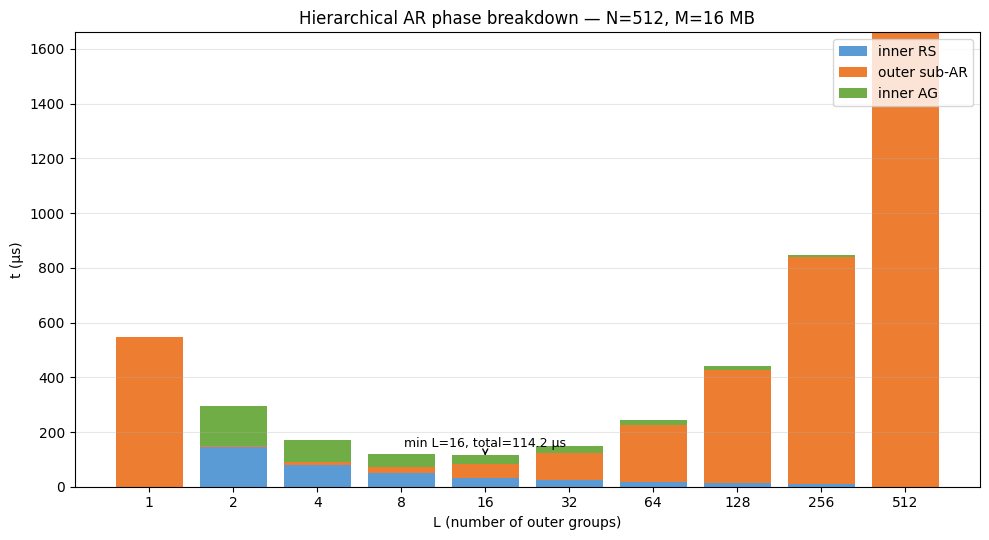

In [3]:
# Stacked-bar phase breakdown
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(df_ar['L'].astype(str), df_ar['inner_RS_us'], label='inner RS', color='#5b9bd5')
ax.bar(df_ar['L'].astype(str), df_ar['outer_AR_us'],
       bottom=df_ar['inner_RS_us'], label='outer sub-AR', color='#ed7d31')
ax.bar(df_ar['L'].astype(str), df_ar['inner_AG_us'],
       bottom=df_ar['inner_RS_us'] + df_ar['outer_AR_us'], label='inner AG', color='#70ad47')
ax.set_xlabel('L (number of outer groups)')
ax.set_ylabel('t (μs)')
ax.set_title(f'Hierarchical AR phase breakdown — N={N}, M={M/1e6:.0f} MB')
ax.legend(loc='upper right'); ax.grid(True, axis='y', alpha=0.3)
# Annotate optimum
i_min = df_ar['total_us'].idxmin()
ax.annotate(f'min L={int(df_ar.loc[i_min, "L"])}, total={df_ar.loc[i_min, "total_us"]:.1f} μs',
            xy=(i_min, df_ar.loc[i_min, 'total_us']),
            xytext=(i_min, df_ar.loc[i_min, 'total_us'] + 30),
            arrowprops={'arrowstyle': '->'}, ha='center', fontsize=9)
plt.tight_layout(); plt.show()


## Optimal L vs outer BW

If the outer tier is fast (close to inner BW) the optimum drifts toward L=N (flat). If the outer tier is slow, you want L small so the outer phase ships less data — but not so small that the inner tier becomes the bottleneck. Sweep outer BW from 10 GB/s (highly oversubscribed scale-out) to 900 GB/s (NVLink everywhere) and find the optimal L for each.

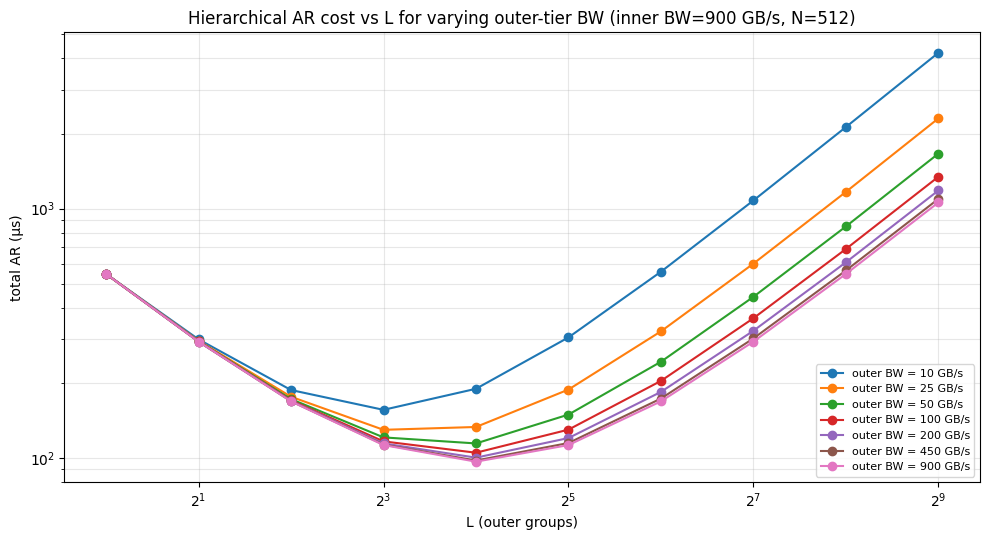

,outer_BW_GB_s,L_optimal,total_us
0,10.0,8,155.750000
1,25.0,8,129.500000
2,50.0,16,114.194444
3,100.0,16,104.819444
4,200.0,16,100.131944
5,450.0,16,97.527778
6,900.0,16,96.486111


In [4]:
# Sweep the outer-tier BW from 10 GB/s (poor scale-out) to 900 GB/s (NVLink everywhere).
# For each outer BW, plot total AR cost vs L; locate optimum.

outer_bws = [10e9, 25e9, 50e9, 100e9, 200e9, 450e9, 900e9]

fig, ax = plt.subplots(figsize=(10, 5.5))
opt_rows = []
for bo_x in outer_bws:
    totals = [hier_ar_breakdown(N, L, M, ai, bi, ao, bo_x)['total_us'] for L in Ls]
    label = f'outer BW = {bo_x/1e9:.0f} GB/s'
    ax.plot(Ls, totals, marker='o', label=label, linewidth=1.5)
    i_opt = min(range(len(Ls)), key=lambda i: totals[i])
    opt_rows.append({'outer_BW_GB_s': bo_x/1e9,
                     'L_optimal': Ls[i_opt],
                     'total_us':   totals[i_opt]})

ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.set_xlabel('L (outer groups)')
ax.set_ylabel('total AR (μs)')
ax.set_title(f'Hierarchical AR cost vs L for varying outer-tier BW (inner BW=900 GB/s, N={N})')
ax.legend(loc='lower right', fontsize=8); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()
pd.DataFrame(opt_rows)


## AR vs AG: telescoping changes the optimum

`03_hierarchical_topologies.md` §2.1 summary table: AR's outer phase carries `M·L/N`, but AG's outer phase carries the full per-rank gathered output. So AG is much less L-sensitive — there's no asymptotic floor that the inner RS unlocks.

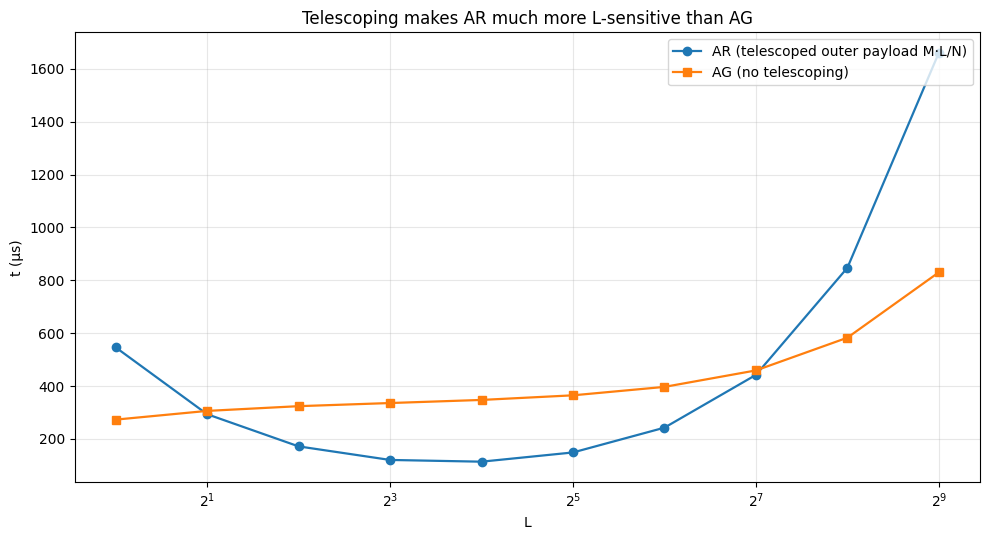

In [5]:
# AG / RS don't get the M·L/N telescope — both inner and outer ship M (or
# proportional to it). Show how that changes the optimal L.

def hier_ag_total(N, L, M, ai, bi, ao, bo):
    if L <= 1:
        return to_us(cc.ring_all_gather(M, N, ai, bi))
    if L >= N:
        return to_us(cc.ring_all_gather(M, N, ao, bo))
    n_inner = N // L
    inner = cc.ring_all_gather(M, n_inner, ai, bi)
    # 03_hierarchical_topologies.md §2.1: outer AG ships per-rank gathered output =
    # n_inner shards' worth, i.e., M (no telescoping for AG/RS).
    outer = cc.ring_all_gather(M, L, ao, bo)
    return to_us(inner + outer)

ag_curve = [hier_ag_total(N, L, M, ai, bi, ao, bo) for L in Ls]
ar_curve = df_ar['total_us'].tolist()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(Ls, ar_curve, marker='o', linewidth=1.6,
        label='AR (telescoped outer payload M·L/N)')
ax.plot(Ls, ag_curve, marker='s', linewidth=1.6,
        label='AG (no telescoping)')
ax.set_xscale('log', base=2)
ax.set_xlabel('L'); ax.set_ylabel('t (μs)')
ax.set_title('Telescoping makes AR much more L-sensitive than AG')
ax.legend(loc='upper right'); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


## Key takeaways

1. **There's a sharp optimum L for AR** at the canonical mix (NVL72 inner + IB outer), and it sits at L=N/n_inner = 8 for the default 64-way scale-up domain. This is why NVL72 is built around 72 GPU groups.
2. **The optimum drifts with BW asymmetry.** As outer BW closes on inner BW, optimal L shifts toward N (any partitioning is fine — flat ring works). At extreme asymmetry (outer ≪ inner), tiny L wins, but with diminishing returns past L=2.
3. **AG/RS need a different strategy.** Without telescoping, the outer-tier phase doesn't shrink with L — so the optimum is dominated by α scaling, not BW asymmetry.
4. **Apply this to TP/EP/PP/DP allocation:** the same composition logic decides which parallelism axis maps to inner vs outer fabric (`03_hierarchical_topologies.md` §3) — communication-heavy axes (TP, EP) get the inner tier, less-frequent ones (DP all-reduce) tolerate the outer tier.